
# Лабораторный Jupyter Notebook: классическое компьютерное зрение для горизонтальных балок и зазоров

Этот ноутбук устроен не как готовая «чёрная коробка», а как учебно-исследовательский стенд. Каждый общий метод компьютерного зрения рассматривается отдельно: сначала даётся его общепринятое название, затем идея, параметры, отдельная функция и обязательная визуализация результата.

Основные общие методы, которые рассматриваются:

1. **Region of Interest (ROI)** — выделение области интереса.
2. **Color-space conversion** — преобразование цветовых пространств RGB/BGR → Gray, HSV, CIE Lab.
3. **Contrast enhancement with CLAHE** — локальная адаптивная нормализация контраста.
4. **Image projection profile** — переход от двумерного изображения к одномерному сигналу посредством агрегации по строкам.
5. **Gaussian smoothing** — подавление высокочастотного шума.
6. **Numerical differentiation / gradient profile** — поиск резких переходов в одномерном сигнале.
7. **Peak detection** — поиск локальных максимумов с параметрами prominence и distance.
8. **Canny edge detection** — двумерный поиск границ.
9. **Connected interval analysis / run-length segmentation** — разбиение вертикальной оси на интервалы между найденными границами.
10. **Handcrafted feature extraction** — извлечение яркостных, цветовых, текстурных и граничных признаков.
11. **Threshold classifier / linear scoring model** — интерпретируемая классификация интервалов `beam/gap`.
12. **Autocorrelation / periodicity analysis** — оценка периодичности повторяющейся структуры.
13. **Template matching** — поиск центрального визуального репера по шаблону.
14. **Image-based visual servoing** — формирование визуальной ошибки движения по точке/линии в изображении.

Главная цель — чтобы любой блок можно было заменить: медиану на среднее, Canny на Sobel, пороговый классификатор на SVM или нейросетевую сегментацию, не переписывая весь ноутбук.


## 0. Зависимости и режим отображения

In [1]:

# При необходимости выполнить один раз:
# %pip install numpy opencv-python matplotlib scipy pandas pyyaml ipywidgets scikit-learn

from __future__ import annotations
from dataclasses import dataclass, asdict, replace
from pathlib import Path
from typing import Optional, Sequence, Callable
import math
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.grid'] = True


## 1. Конфигурация: все параметры собраны в одном месте

In [38]:

@dataclass
class CVConfig:
    # ROI в нормированных координатах [0, 1].
    roi_x0: float = 0.1
    roi_x1: float = 0.8
    roi_y0: float = 0.7
    roi_y1: float = 1.00

    # Цветовой канал, по которому строится projection profile.
    # Доступны: gray, L, a, b, H, S, V.
    profile_channel: str = 'V'

    # Агрегатор строки: median, mean, quantile.
    row_aggregator: str = 'median'
    row_quantile: float = 0.50

    # CLAHE.
    use_clahe: bool = True
    clahe_clip_limit: float = 2.0
    clahe_grid_size: int = 8

    # Gaussian smoothing одномерного профиля.
    gaussian_kernel: int =  9

    # Peak detection.
    peak_prominence: float = 4.0
    peak_distance_px: int = 8
    max_peaks: int = 100

    # Фильтрация интервалов.
    min_interval_height_px: int = 4
    max_interval_height_px: int = 100

    # Canny.
    canny_low: int = 50
    canny_high: int = 150

    # Линейный score-классификатор интервалов.
    weight_darkness: float = 1.0
    weight_edge_density: float = 0.5
    weight_texture: float = 0.2
    score_threshold: float = 0.0

    # Visual servoing.
    desired_u_norm: float = 0.50
    handoff_v_norm: float = 0.78

cfg = CVConfig()

# Исправляем поле, чтобы оно оставалось обычным числом и легко редактировалось.
cfg.gaussian_kernel = 9
print(cfg)


CVConfig(roi_x0=0.1, roi_x1=0.8, roi_y0=0.7, roi_y1=1.0, profile_channel='V', row_aggregator='median', row_quantile=0.5, use_clahe=True, clahe_clip_limit=2.0, clahe_grid_size=8, gaussian_kernel=9, peak_prominence=4.0, peak_distance_px=8, max_peaks=100, min_interval_height_px=4, max_interval_height_px=100, canny_low=50, canny_high=150, weight_darkness=1.0, weight_edge_density=0.5, weight_texture=0.2, score_threshold=0.0, desired_u_norm=0.5, handoff_v_norm=0.78)



> Важный принцип модифицируемости: функции ниже не используют глобальные пороги напрямую. Все изменяемые параметры передаются через `cfg`. Поэтому можно создавать несколько конфигураций и сравнивать их на одних данных.


## 2. Загрузка набора изображений и браузер данных

Найдено изображений: 40
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000210.png
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000211.5.png
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000211.png
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000212.png
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000213.png
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000214.png
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000215.png
/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames/frame_000216.pn

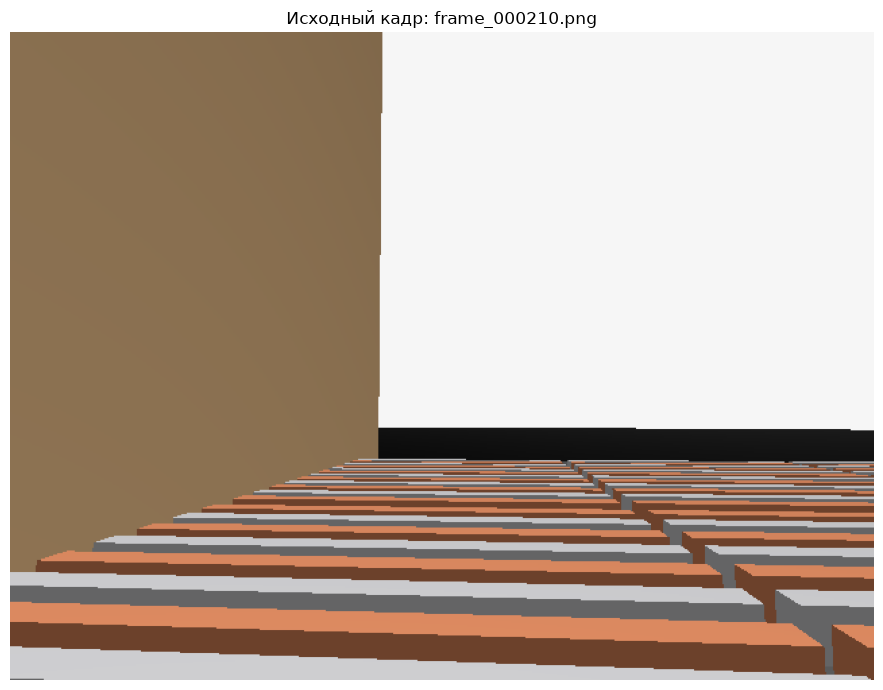

In [53]:

DATA_DIR = Path('/Users/kamiliskhakov/VS Code Project/RTK2026/records/experiments/electrolysis_20260727_120058/rgb_frames')
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

def find_images(root: Path = DATA_DIR) -> list[Path]:
    return sorted(p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

def load_bgr(path: str | Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return image

def show_images(images, titles=None, cols=4, figsize=(18, 10), cmaps=None):
    """Универсальная функция показа группы изображений."""
    n = len(images)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    titles = titles or [''] * n
    cmaps = cmaps or [None] * n
    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis('off'); continue
        img = images[i]
        if img.ndim == 3:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(img, cmap=cmaps[i] or 'gray')
        ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout(); plt.show()

image_paths = find_images()[210:250]
print(f'Найдено изображений: {len(image_paths)}')
for p in image_paths[:20]: print(p)

# Индекс можно менять вручную.
IMAGE_INDEX = 0
frame_bgr = load_bgr(image_paths[IMAGE_INDEX]) if image_paths else None
if frame_bgr is not None:
    show_images([frame_bgr], [f'Исходный кадр: {image_paths[IMAGE_INDEX].name}'], cols=1, figsize=(12,7))



## 3. Region of Interest (ROI)

**Общее название метода:** Region of Interest selection / cropping.

ROI не является детектором. Это априорное ограничение области, в которой допустимо искать балки. Оно уменьшает число ложных объектов и вычислительную нагрузку.

Параметры `roi_x0, roi_x1, roi_y0, roi_y1` задаются в долях исходного размера, поэтому не зависят от разрешения камеры.


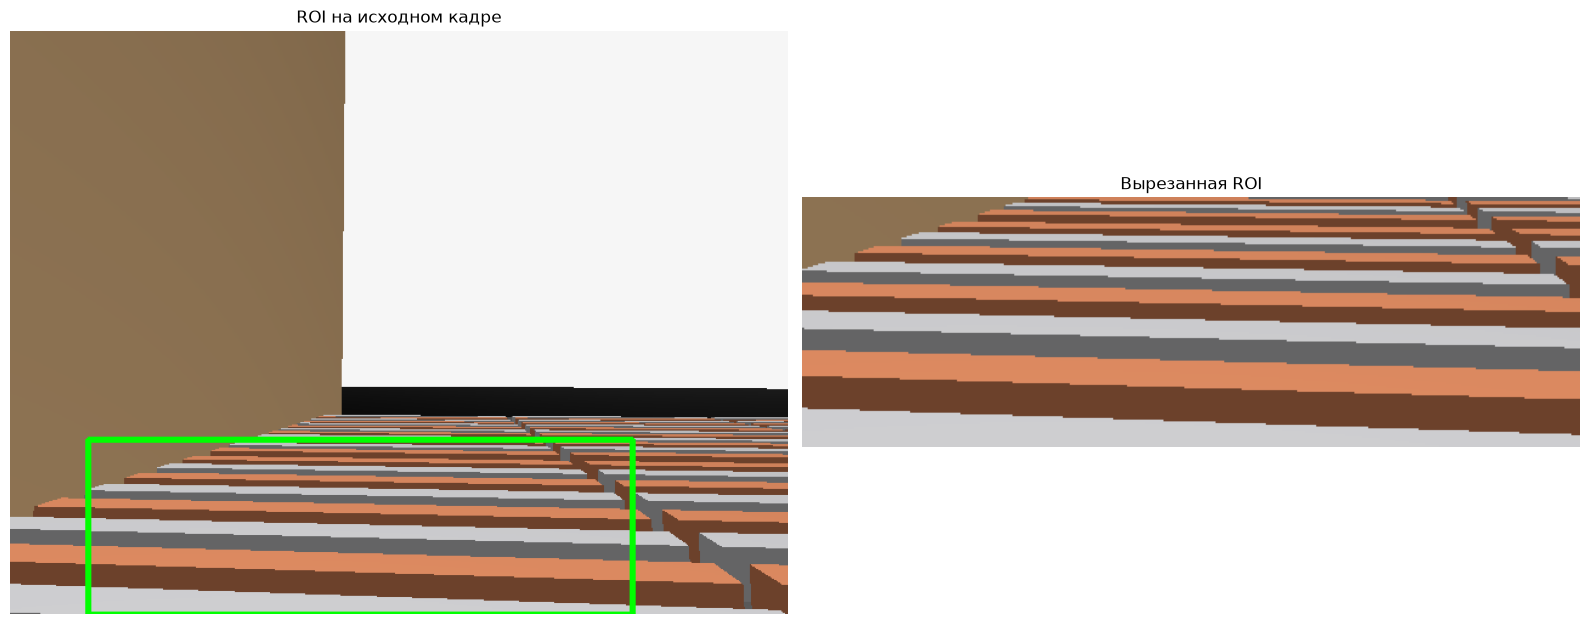

In [54]:

def crop_roi(image: np.ndarray, cfg: CVConfig):
    h, w = image.shape[:2]
    x0 = int(np.clip(cfg.roi_x0, 0, 1) * w)
    x1 = int(np.clip(cfg.roi_x1, 0, 1) * w)
    y0 = int(np.clip(cfg.roi_y0, 0, 1) * h)
    y1 = int(np.clip(cfg.roi_y1, 0, 1) * h)
    if x1 <= x0 or y1 <= y0:
        raise ValueError('Некорректная ROI')
    return image[y0:y1, x0:x1].copy(), (x0, y0)

if frame_bgr is not None:
    roi_bgr, roi_offset = crop_roi(frame_bgr, cfg)
    overlay = frame_bgr.copy()
    x0, y0 = roi_offset
    cv2.rectangle(overlay, (x0,y0), (x0+roi_bgr.shape[1], y0+roi_bgr.shape[0]), (0,255,0), 3)
    show_images([overlay, roi_bgr], ['ROI на исходном кадре', 'Вырезанная ROI'], cols=2, figsize=(16,7))



## 4. Color-space conversion и CLAHE

**Общие методы:**

- grayscale conversion;
- HSV color space;
- CIE Lab color space;
- Contrast Limited Adaptive Histogram Equalization (CLAHE).

Lab полезен тем, что канал `L` описывает яркость, а `a,b` — цветность. CLAHE локально растягивает контраст, но ограничивает усиление шума параметром `clipLimit`.

Что менять:

- `clahe_clip_limit`: больше — сильнее локальный контраст, но больше шум;
- `clahe_grid_size`: меньше ячейки — более локальная коррекция;
- `profile_channel`: канал, который затем агрегируется по строкам.


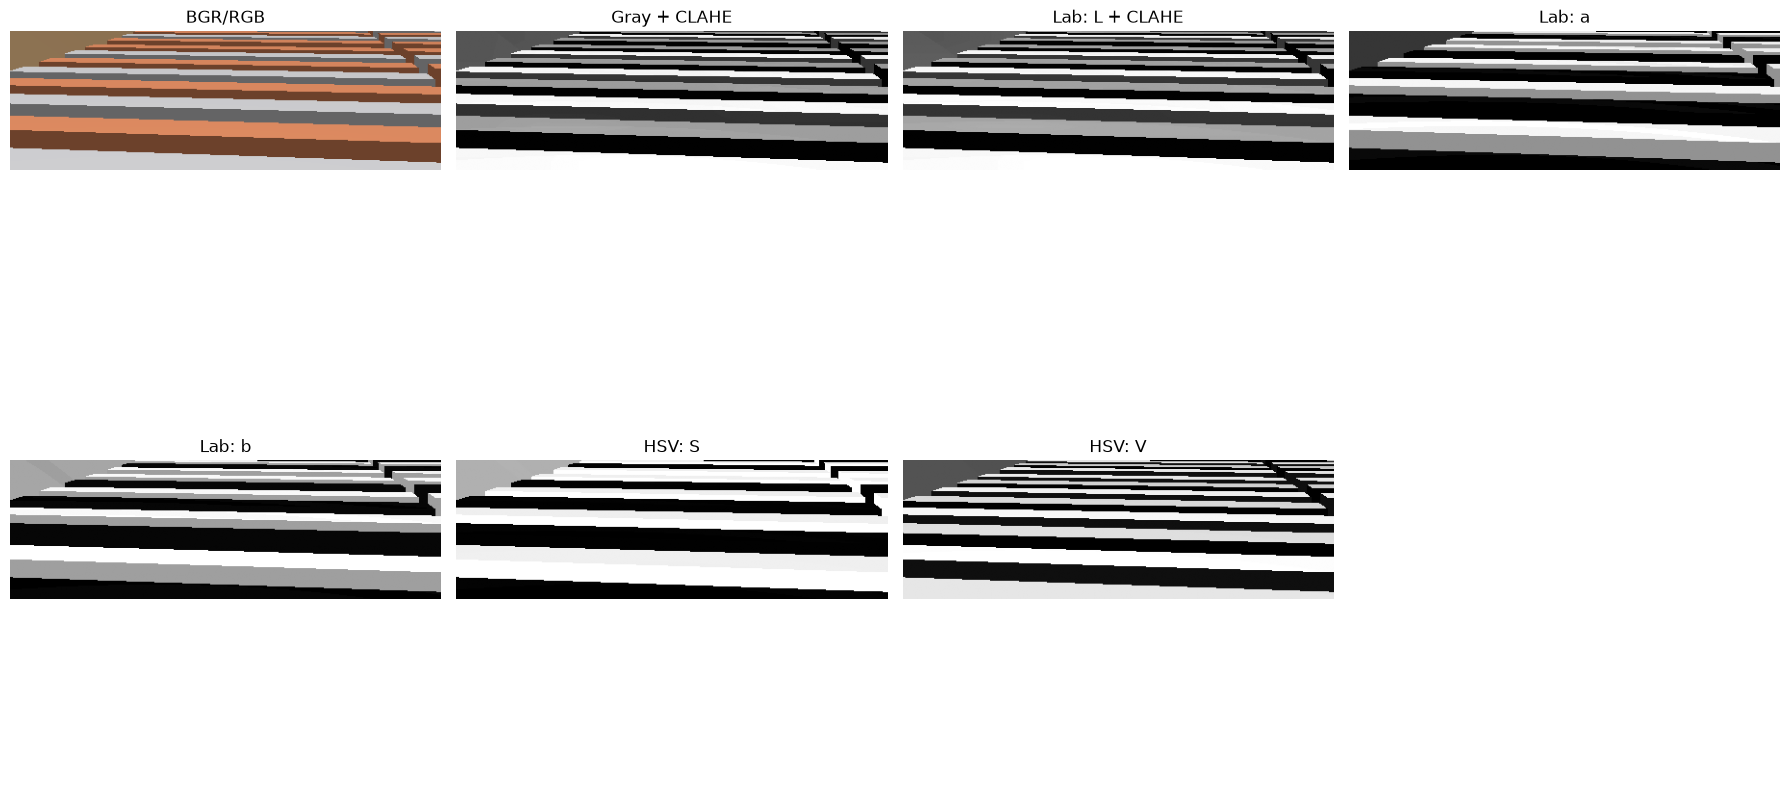

In [55]:

def compute_channels(image_bgr: np.ndarray, cfg: CVConfig) -> dict[str, np.ndarray]:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    L, a, b = cv2.split(lab)
    H, S, V = cv2.split(hsv)

    if cfg.use_clahe:
        clahe = cv2.createCLAHE(
            clipLimit=cfg.clahe_clip_limit,
            tileGridSize=(cfg.clahe_grid_size, cfg.clahe_grid_size),
        )
        L_processed = clahe.apply(L)
        gray_processed = clahe.apply(gray)
    else:
        L_processed, gray_processed = L, gray

    return {
        'gray': gray_processed, 'L': L_processed, 'a': a, 'b': b,
        'H': H, 'S': S, 'V': V, 'lab': lab, 'hsv': hsv,
    }

if frame_bgr is not None:
    channels = compute_channels(roi_bgr, cfg)
    show_images(
        [roi_bgr, channels['gray'], channels['L'], channels['a'], channels['b'], channels['S'], channels['V']],
        ['BGR/RGB', 'Gray + CLAHE', 'Lab: L + CLAHE', 'Lab: a', 'Lab: b', 'HSV: S', 'HSV: V'],
        cols=4, figsize=(18,10)
    )



## 5. Image Projection Profile: переход от 2D-изображения к 1D-сигналу

**Общее название метода:** projection profile / integral projection / row projection.

Пусть выбран одноканальный образ `I(u,v)`. Для каждой строки вычисляется агрегат по горизонтальной координате:


a) среднее:

$$
p(v)=\frac{1}{W}\sum_{u=1}^{W}I(u,v),
$$

b) медиана:

$$
p(v)=\operatorname{median}_{u} I(u,v),
$$

c) квантиль:

$$
p_q(v)=Q_q\{I(u,v)\}_{u=1}^{W}.
$$

Медиана и квантили относятся к **robust statistics**: они слабее реагируют на отдельные блики, надписи и локальные загрязнения. Среднее лучше сохраняет суммарный сигнал, но чувствительнее к выбросам.

Что менять:

- `profile_channel`: какой физический признак агрегируется;
- `row_aggregator`: `mean`, `median`, `quantile`;
- `row_quantile`: например, `0.25` акцентирует тёмную часть строки, `0.75` — светлую.


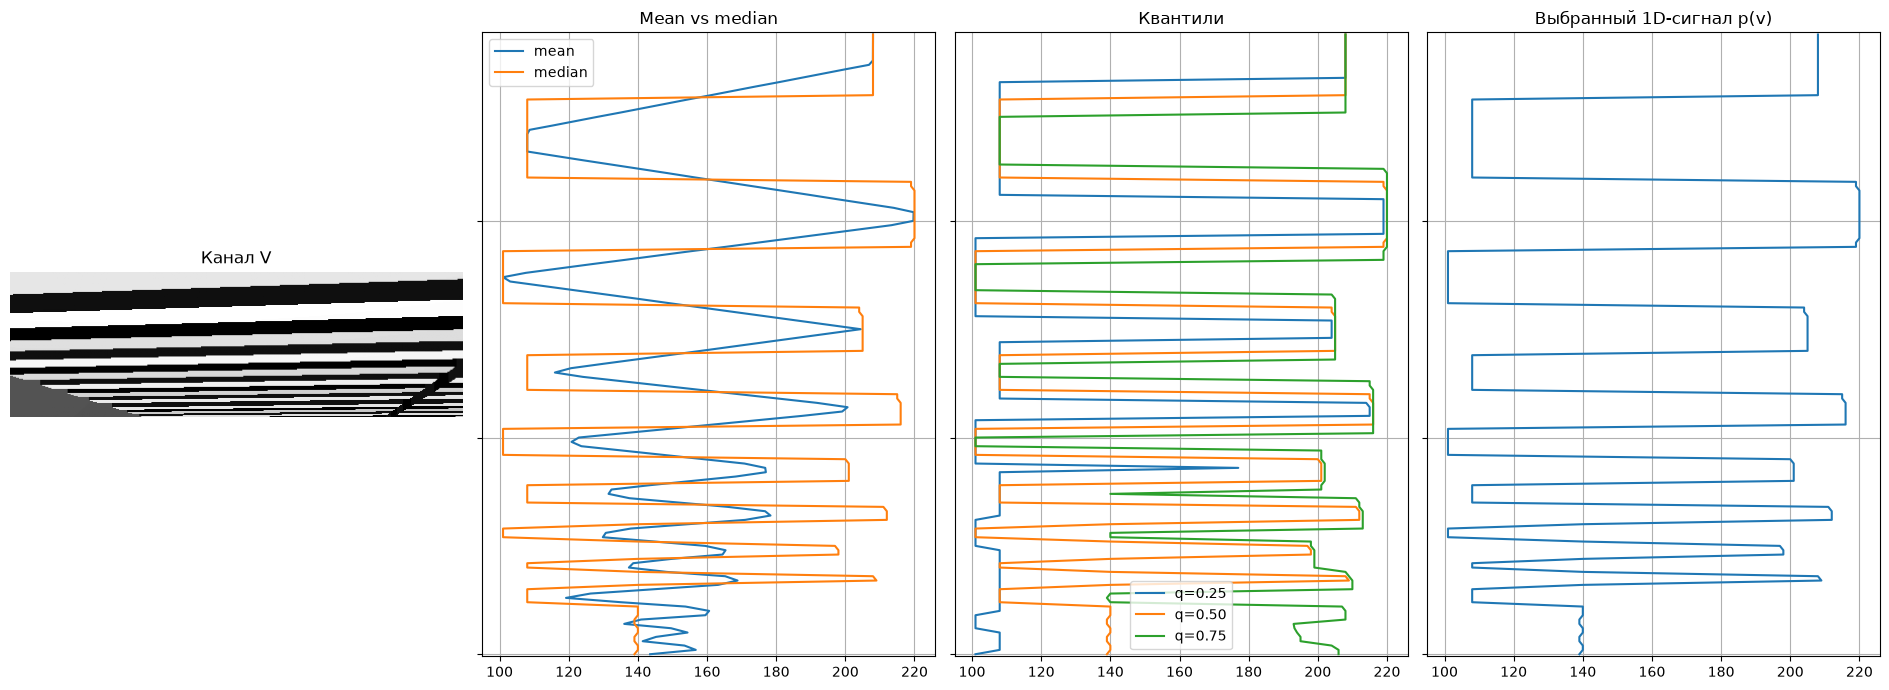

In [56]:

def row_projection(channel: np.ndarray, method='median', q=0.5) -> np.ndarray:
    x = channel.astype(np.float32)
    if method == 'mean':
        return x.mean(axis=1)
    if method == 'median':
        return np.median(x, axis=1)
    if method == 'quantile':
        return np.quantile(x, q, axis=1)
    raise ValueError(f'Неизвестный aggregator: {method}')

if frame_bgr is not None:
    selected = channels[cfg.profile_channel]
    p_mean = row_projection(selected, 'mean')
    p_median = row_projection(selected, 'median')
    p_q25 = row_projection(selected, 'quantile', 0.25)
    p_q75 = row_projection(selected, 'quantile', 0.75)
    y = np.arange(selected.shape[0])

    fig, axes = plt.subplots(1, 4, figsize=(19,7), sharey=True)
    axes[0].imshow(selected, cmap='gray'); axes[0].set_title(f'Канал {cfg.profile_channel}'); axes[0].axis('off')
    axes[1].plot(p_mean,y,label='mean'); axes[1].plot(p_median,y,label='median'); axes[1].invert_yaxis(); axes[1].legend(); axes[1].set_title('Mean vs median')
    axes[2].plot(p_q25,y,label='q=0.25'); axes[2].plot(p_median,y,label='q=0.50'); axes[2].plot(p_q75,y,label='q=0.75'); axes[2].invert_yaxis(); axes[2].legend(); axes[2].set_title('Квантили')
    axes[3].plot(p_median,y); axes[3].invert_yaxis(); axes[3].set_title('Выбранный 1D-сигнал p(v)')
    plt.tight_layout(); plt.show()

    raw_profile = row_projection(selected, cfg.row_aggregator, cfg.row_quantile)



## 6. Gaussian smoothing одномерного сигнала

**Общее название метода:** Gaussian low-pass filtering / Gaussian smoothing.

Сглаживание вычисляет свёртку профиля с гауссовым ядром. Оно подавляет мелкие высокочастотные флуктуации перед численным дифференцированием.

Главный параметр — `gaussian_kernel`:

- слишком малый: остаются шумовые пики;
- слишком большой: соседние физические границы сливаются и смещаются.


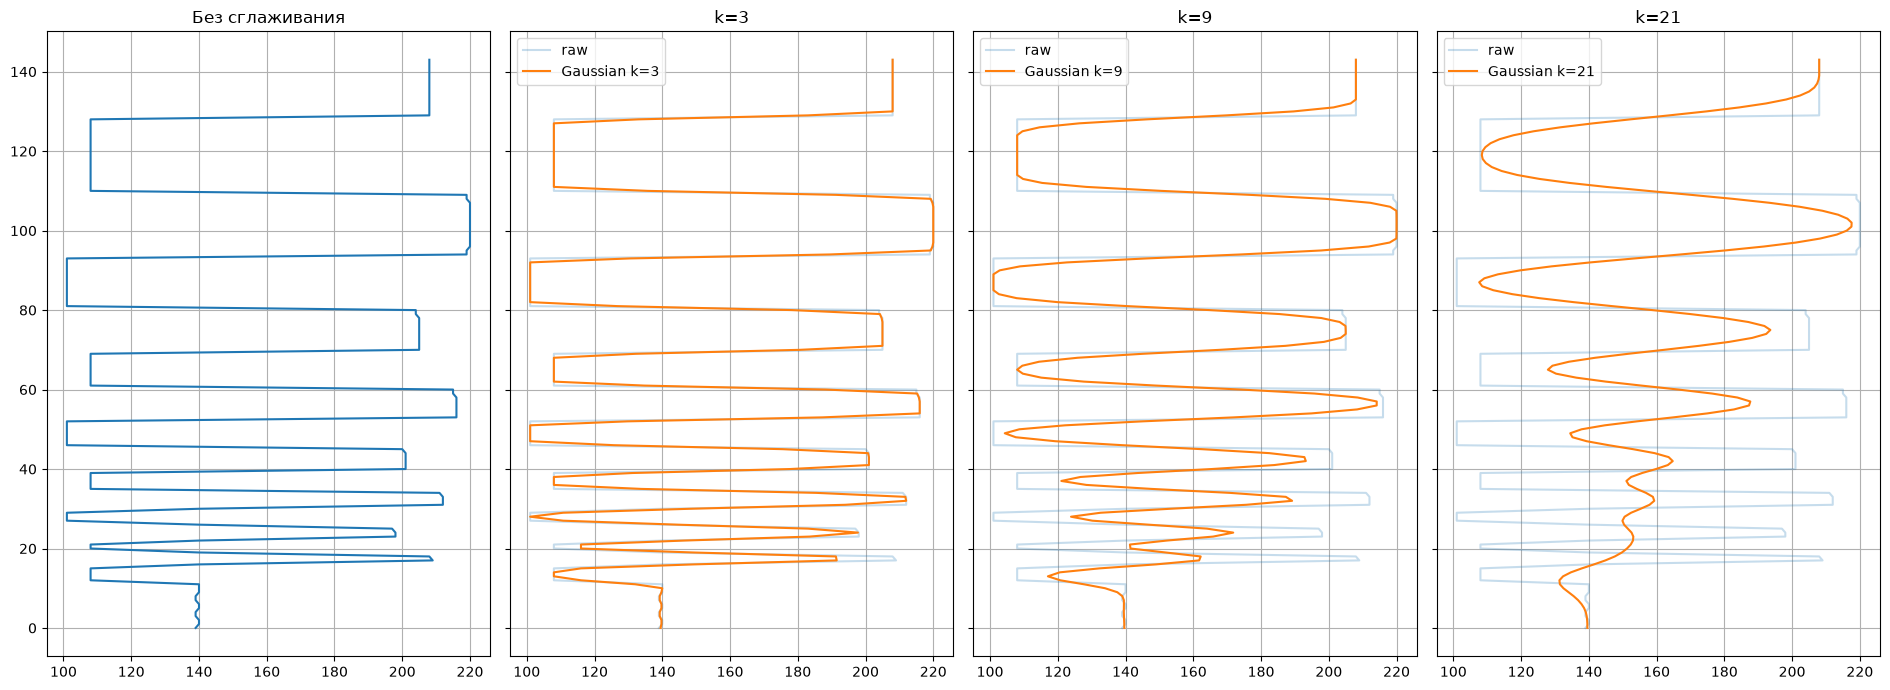

In [57]:

def gaussian_smooth_1d(profile: np.ndarray, kernel: int) -> np.ndarray:
    kernel = max(3, int(kernel))
    if kernel % 2 == 0:
        kernel += 1
    return cv2.GaussianBlur(profile.reshape(-1,1).astype(np.float32), (1,kernel), 0).ravel()

if frame_bgr is not None:
    kernels = [3, 9, 21]
    smoothed_versions = [gaussian_smooth_1d(raw_profile,k) for k in kernels]
    y=np.arange(len(raw_profile))
    fig,axes=plt.subplots(1,4,figsize=(19,7),sharey=True)
    axes[0].plot(raw_profile,y); axes[0].invert_yaxis(); axes[0].set_title('Без сглаживания')
    for ax,k,p in zip(axes[1:],kernels,smoothed_versions):
        ax.plot(raw_profile,y,alpha=.25,label='raw'); ax.plot(p,y,label=f'Gaussian k={k}'); ax.invert_yaxis(); ax.legend(); ax.set_title(f'k={k}')
    plt.tight_layout(); plt.show()
    smooth_profile = gaussian_smooth_1d(raw_profile,cfg.gaussian_kernel)



## 7. Numerical gradient и Peak Detection

**Общие методы:** numerical differentiation и peak detection.

Граница полосы соответствует резкому изменению профиля. Поэтому строится

$$
g(v)=\left|\frac{dp(v)}{dv}\right|.
$$

После этого используется `scipy.signal.find_peaks`.

Параметры:

- `prominence`: насколько пик должен возвышаться над локальным окружением; основной параметр подавления ложных пиков;
- `distance`: минимальное расстояние между пиками; предотвращает многократную детекцию одной границы;
- `height` можно добавить отдельно, если нужен абсолютный порог амплитуды.


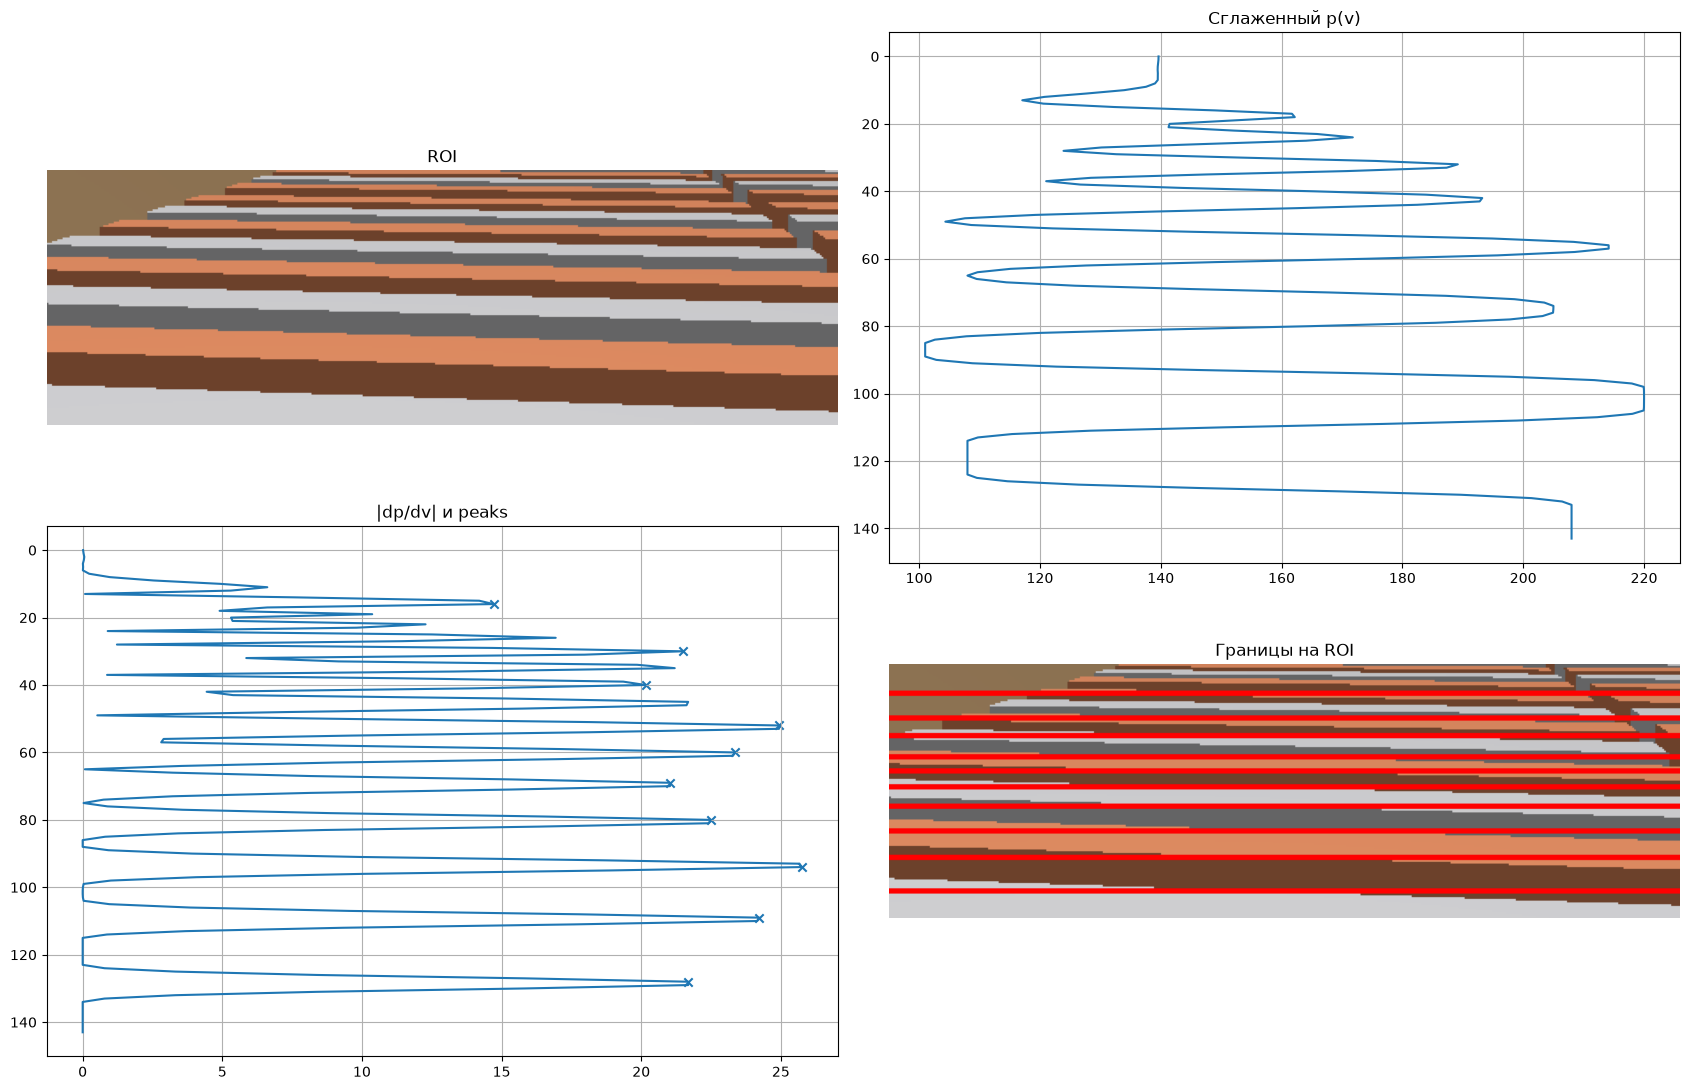

In [58]:

def detect_peaks_from_profile(profile: np.ndarray, cfg: CVConfig):
    gradient = np.abs(np.gradient(profile))
    peaks, props = find_peaks(
        gradient,
        prominence=cfg.peak_prominence,
        distance=cfg.peak_distance_px,
    )
    if len(peaks) > cfg.max_peaks:
        keep=np.argsort(props['prominences'])[-cfg.max_peaks:]
        peaks=np.sort(peaks[keep])
    return gradient, peaks, props

if frame_bgr is not None:
    gradient, boundaries, peak_props = detect_peaks_from_profile(smooth_profile,cfg)
    y=np.arange(len(gradient))
    overlay=roi_bgr.copy()
    for v in boundaries: cv2.line(overlay,(0,int(v)),(overlay.shape[1]-1,int(v)),(0,0,255),2)
    fig,axes=plt.subplots(2,2,figsize=(17,11))
    axes[0,0].imshow(cv2.cvtColor(roi_bgr,cv2.COLOR_BGR2RGB)); axes[0,0].set_title('ROI'); axes[0,0].axis('off')
    axes[0,1].plot(smooth_profile,y); axes[0,1].invert_yaxis(); axes[0,1].set_title('Сглаженный p(v)')
    axes[1,0].plot(gradient,y); axes[1,0].scatter(gradient[boundaries],boundaries,marker='x'); axes[1,0].invert_yaxis(); axes[1,0].set_title('|dp/dv| и peaks')
    axes[1,1].imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB)); axes[1,1].set_title('Границы на ROI'); axes[1,1].axis('off')
    plt.tight_layout(); plt.show()



## 8. Canny Edge Detection как независимая 2D-диагностика

**Общее название метода:** Canny edge detector.

Canny выполняет сглаживание, вычисление градиента, non-maximum suppression и hysteresis thresholding. В текущем пайплайне он не заменяет projection profile, а даёт независимый признак `edge_density` для каждого интервала.

Параметры `canny_low`, `canny_high`:

- ниже пороги — больше слабых границ и шума;
- выше пороги — остаются только сильные контуры.


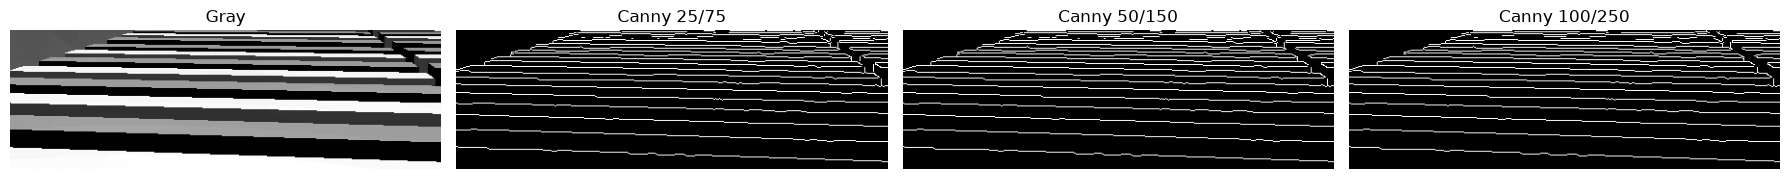

In [59]:

if frame_bgr is not None:
    canny_variants=[]; titles=[]
    for low,high in [(25,75),(50,150),(100,250)]:
        canny_variants.append(cv2.Canny(channels['gray'],low,high)); titles.append(f'Canny {low}/{high}')
    show_images([channels['gray'],*canny_variants],['Gray',*titles],cols=4,figsize=(18,7))
    edge_map=cv2.Canny(channels['gray'],cfg.canny_low,cfg.canny_high)



## 9. Run-length / interval segmentation

**Общее название метода:** interval segmentation between ordered change points; близкая идея — run-length segmentation.

Упорядоченные пики `v_1,...,v_n` делят ось изображения на интервалы. На этом шаге пока не решается, что является балкой, а что зазором. Формируются только кандидаты и геометрические признаки.


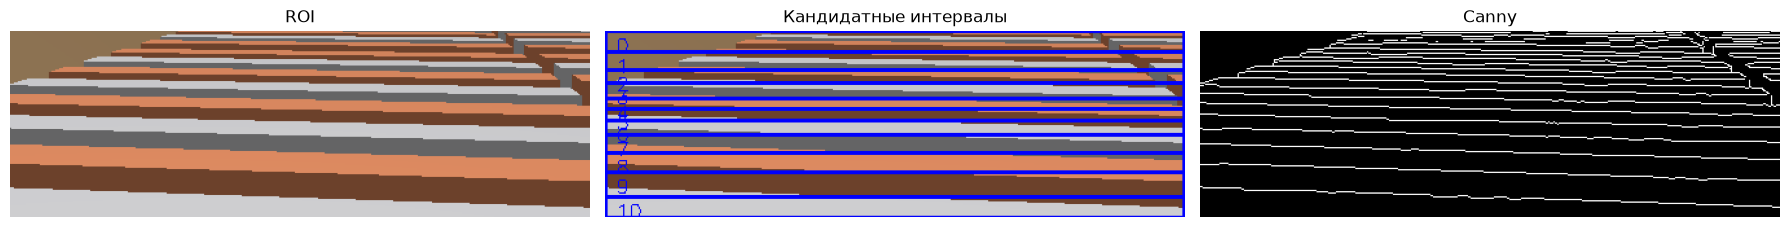

,top,bottom,center_v,height,mean_L,mean_a,mean_b,std_gray,edge_density,darkness,texture_rel,score,label,confidence
0,0,16,8.0,16,124.887277,139.783482,146.357143,39.435238,0.216518,0.0,0.0,0.0,unknown,0.0
1,16,30,23.0,14,134.798310,137.735969,142.112085,48.411045,0.234375,0.0,0.0,0.0,unknown,0.0
2,30,40,35.0,10,125.393750,144.493304,149.767634,43.174339,0.187500,0.0,0.0,0.0,unknown,0.0
3,40,52,46.0,12,148.678385,131.190662,130.790551,53.715481,0.156994,0.0,0.0,0.0,unknown,0.0
4,52,60,56.0,8,143.289342,148.074219,153.344029,30.814619,0.128627,0.0,0.0,0.0,unknown,0.0
5,60,69,64.5,9,108.519593,145.003472,149.995040,45.655098,0.099454,0.0,0.0,0.0,unknown,0.0
6,69,80,74.5,11,176.846794,131.344359,131.044643,55.366768,0.101664,0.0,0.0,0.0,unknown,0.0
7,80,94,87.0,14,128.707908,131.047672,130.977679,39.568657,0.078284,0.0,0.0,0.0,unknown,0.0
8,94,109,101.5,15,151.983482,151.505208,158.007143,29.210598,0.063244,0.0,0.0,0.0,unknown,0.0
9,109,128,118.5,19,100.557213,144.085291,148.768445,41.510044,0.048990,0.0,0.0,0.0,unknown,0.0


In [60]:

@dataclass
class Interval:
    top:int; bottom:int; center_v:float; height:int
    mean_L:float; mean_a:float; mean_b:float
    std_gray:float; edge_density:float
    darkness:float=0.0; texture_rel:float=0.0
    score:float=0.0; label:str='unknown'; confidence:float=0.0

def build_candidate_intervals(channels, edge_map, boundaries, cfg):
    h=channels['gray'].shape[0]
    bounds=np.unique(np.concatenate(([0],boundaries,[h]))).astype(int)
    result=[]
    for top,bottom in zip(bounds[:-1],bounds[1:]):
        height=bottom-top
        if not cfg.min_interval_height_px <= height <= cfg.max_interval_height_px:
            continue
        lab_patch=channels['lab'][top:bottom]
        gray_patch=channels['gray'][top:bottom]
        edge_patch=edge_map[top:bottom]
        mean_lab=lab_patch.reshape(-1,3).mean(axis=0)
        result.append(Interval(
            top=int(top),bottom=int(bottom),center_v=(top+bottom)/2,height=int(height),
            mean_L=float(mean_lab[0]),mean_a=float(mean_lab[1]),mean_b=float(mean_lab[2]),
            std_gray=float(gray_patch.astype(np.float32).std()),
            edge_density=float((edge_patch>0).mean()),
        ))
    return result

if frame_bgr is not None:
    candidates=build_candidate_intervals(channels,edge_map,boundaries,cfg)
    candidate_overlay=roi_bgr.copy()
    for i,r in enumerate(candidates):
        cv2.rectangle(candidate_overlay,(0,r.top),(candidate_overlay.shape[1]-1,r.bottom),(255,0,0),2)
        cv2.putText(candidate_overlay,str(i),(8,r.top+16),cv2.FONT_HERSHEY_SIMPLEX,.5,(255,0,0),1)
    show_images([roi_bgr,candidate_overlay,edge_map],['ROI','Кандидатные интервалы','Canny'],cols=3,figsize=(18,7))
    display(pd.DataFrame([asdict(x) for x in candidates]))



## 10. Handcrafted feature extraction и линейный threshold classifier

**Общие методы:** handcrafted feature extraction и linear discriminant score / threshold classifier.

Это прозрачный baseline. Он не является общепринятым универсальным детектором зазоров; общими методами являются сами признаки и пороговая классификация.

Используем нормированные признаки:

- `darkness`: насколько интервал темнее медианной яркости кадра;
- `edge_density`: доля Canny-пикселей;
- `texture_rel`: относительная текстурность.

Линейный score:

\[
s_i=w_d d_i+w_e e_i+w_t t_i.
\]

Решение:

\[
s_i\ge T \Rightarrow gap.
\]

Эту функцию легко заменить на Logistic Regression, SVM, Random Forest или CNN, оставив интерфейс прежним.


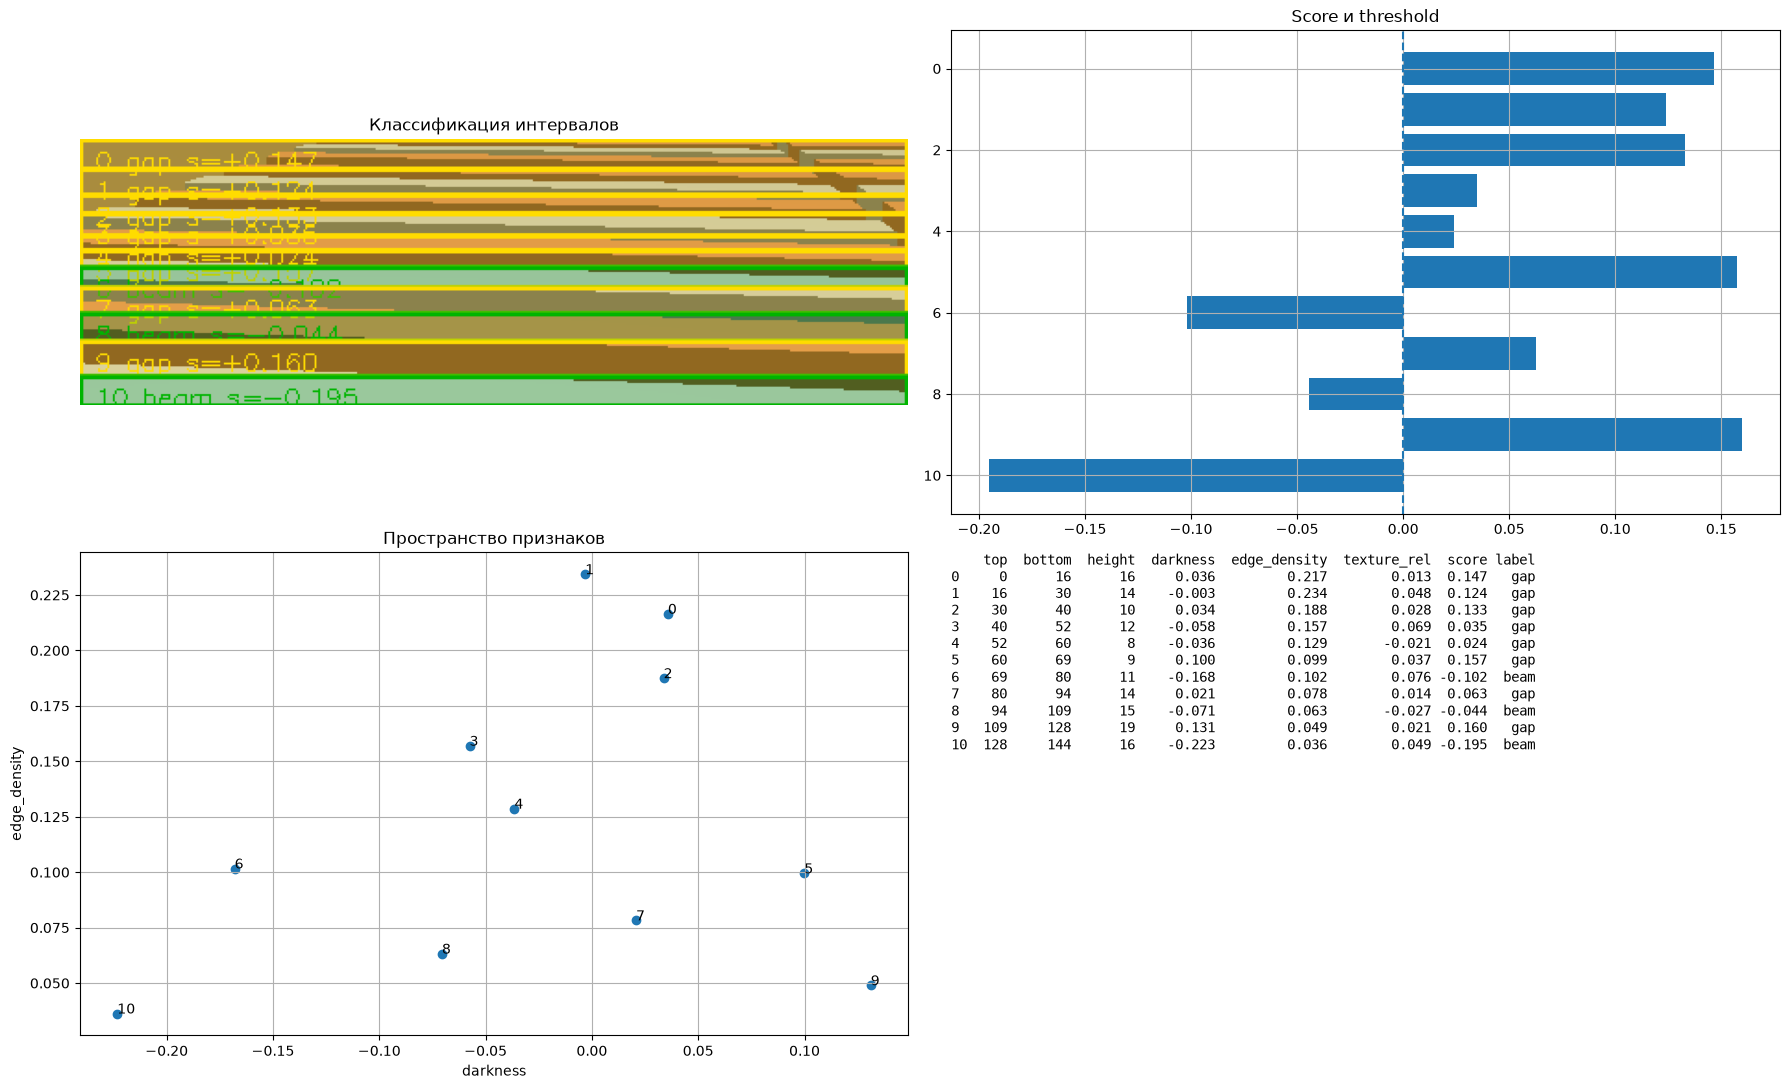

In [61]:

def classify_intervals(intervals: list[Interval], channels, cfg):
    global_L=float(np.median(channels['L']))
    global_texture=float(np.median(channels['gray'].astype(np.float32).std(axis=1)))
    out=[]
    for r in intervals:
        r=replace(r)
        r.darkness=(global_L-r.mean_L)/255.0
        r.texture_rel=(r.std_gray-global_texture)/255.0
        r.score=(cfg.weight_darkness*r.darkness + cfg.weight_edge_density*r.edge_density + cfg.weight_texture*r.texture_rel)
        r.label='gap' if r.score>=cfg.score_threshold else 'beam'
        r.confidence=float(1/(1+np.exp(-8*abs(r.score-cfg.score_threshold))))
        out.append(r)
    return out

if frame_bgr is not None:
    intervals=classify_intervals(candidates,channels,cfg)
    classified=roi_bgr.copy(); tint=roi_bgr.copy()
    for i,r in enumerate(intervals):
        color=(0,220,255) if r.label=='gap' else (0,180,0)
        cv2.rectangle(tint,(0,r.top),(tint.shape[1]-1,r.bottom),color,-1)
        cv2.rectangle(classified,(0,r.top),(classified.shape[1]-1,r.bottom),color,2)
        cv2.putText(classified,f'{i} {r.label} s={r.score:+.3f}',(8,r.top+16),cv2.FONT_HERSHEY_SIMPLEX,.45,color,1)
    classified=cv2.addWeighted(classified,.75,tint,.25,0)
    df=pd.DataFrame([asdict(x) for x in intervals])
    fig,axes=plt.subplots(2,2,figsize=(18,11))
    axes[0,0].imshow(cv2.cvtColor(classified,cv2.COLOR_BGR2RGB)); axes[0,0].set_title('Классификация интервалов'); axes[0,0].axis('off')
    axes[0,1].barh(np.arange(len(df)),df['score']); axes[0,1].axvline(cfg.score_threshold,linestyle='--'); axes[0,1].invert_yaxis(); axes[0,1].set_title('Score и threshold')
    axes[1,0].scatter(df['darkness'],df['edge_density']);
    for i,row in df.iterrows(): axes[1,0].annotate(str(i),(row['darkness'],row['edge_density']))
    axes[1,0].set_xlabel('darkness'); axes[1,0].set_ylabel('edge_density'); axes[1,0].set_title('Пространство признаков')
    axes[1,1].axis('off'); axes[1,1].text(0,1,df[['top','bottom','height','darkness','edge_density','texture_rel','score','label']].round(3).to_string(index=True),family='monospace',va='top')
    plt.tight_layout(); plt.show()



## 11. Autocorrelation: анализ периодичности

**Общее название метода:** autocorrelation analysis.

Для периодической последовательности балок автокорреляция профиля имеет максимумы на лагах, соответствующих периоду и его кратным. Это полезная диагностика и независимая проверка шага структуры.


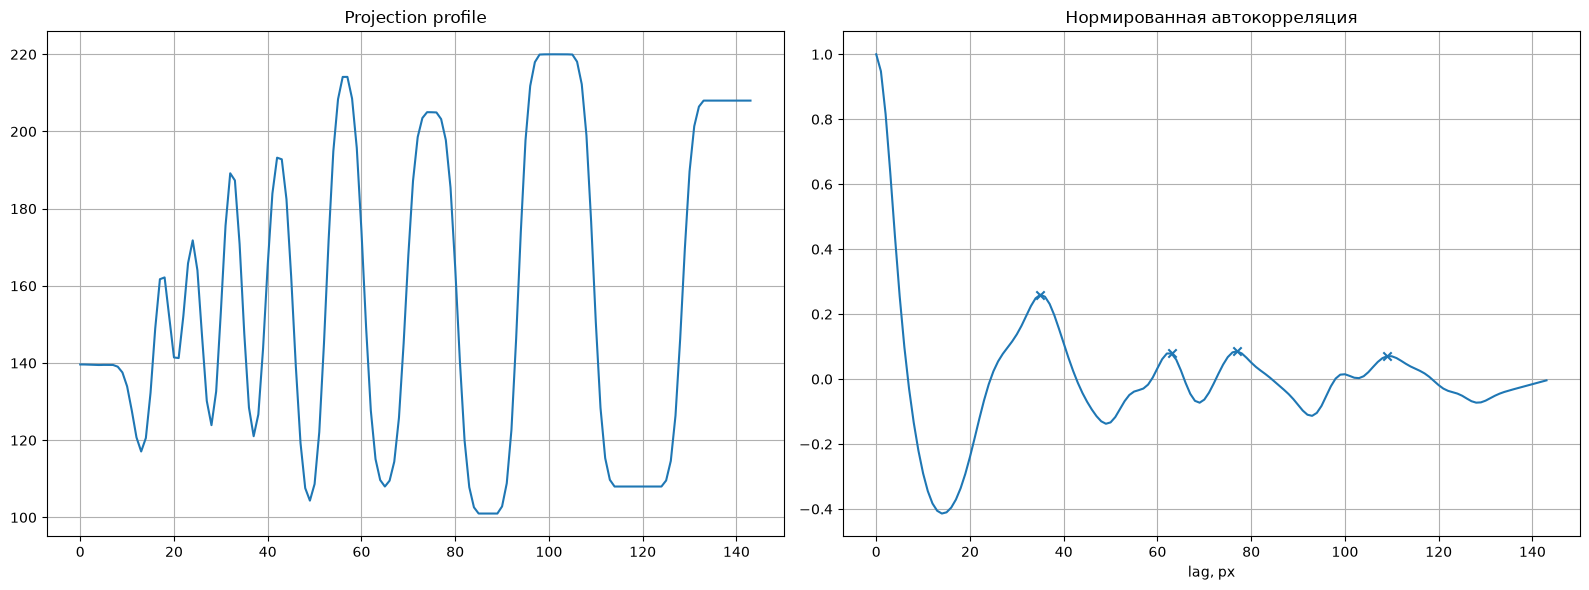

Кандидатные периоды, px: [35, 63, 77, 109]


In [62]:

def normalized_autocorrelation(x):
    x=np.asarray(x,dtype=float); x=x-x.mean()
    ac=np.correlate(x,x,mode='full')[len(x)-1:]
    return ac/(ac[0]+1e-12)

if frame_bgr is not None:
    ac=normalized_autocorrelation(smooth_profile)
    max_lag=min(len(ac),200)
    ac_peaks,_=find_peaks(ac[1:max_lag],prominence=.05)
    ac_peaks=ac_peaks+1
    fig,axes=plt.subplots(1,2,figsize=(16,6))
    axes[0].plot(smooth_profile); axes[0].set_title('Projection profile')
    axes[1].plot(np.arange(max_lag),ac[:max_lag]); axes[1].scatter(ac_peaks,ac[ac_peaks],marker='x'); axes[1].set_title('Нормированная автокорреляция'); axes[1].set_xlabel('lag, px')
    plt.tight_layout(); plt.show()
    print('Кандидатные периоды, px:',ac_peaks[:10].tolist())



## 12. Image-based visual servoing: визуальная цель движения

**Общее название метода:** Image-Based Visual Servoing (IBVS).

Управление использует ошибку непосредственно в координатах изображения. Для горизонтального зазора достаточно центра `(u,v)` и при необходимости угла линии.

$$
e_u=u-u^*,\qquad e_v=v_h-v.
$$

`v_h` — handoff-line: после её пересечения зазор может уйти под капот, и оставшееся расстояние проходится по энкодерам.


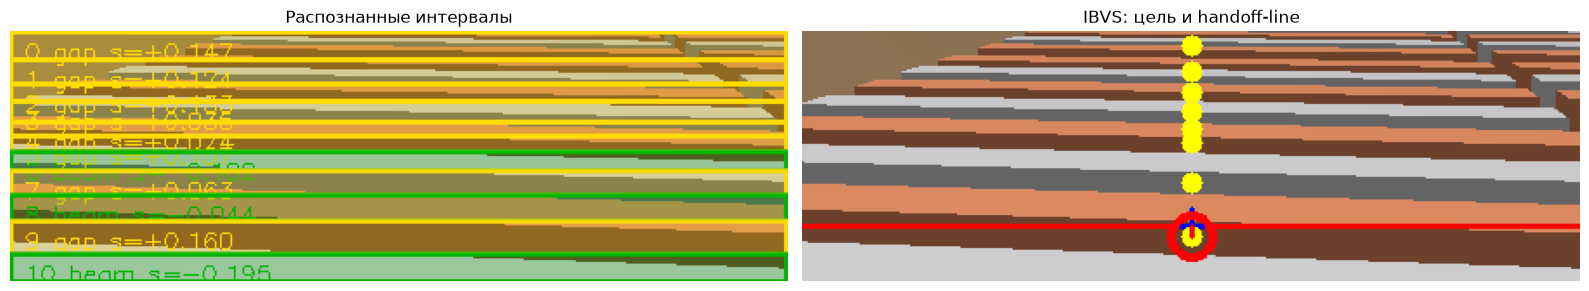

{'target_u': 224.0, 'target_v': np.float64(118.5), 'error_u': 0.0, 'error_v': np.float64(-6.5), 'handoff': np.True_}


In [63]:

def extract_gap_centers(intervals, image_width):
    return [(image_width/2,r.center_v,r) for r in intervals if r.label=='gap']

def draw_visual_servo_debug(image, intervals, cfg):
    out=image.copy(); h,w=out.shape[:2]
    desired_u=int(cfg.desired_u_norm*w); handoff_v=int(cfg.handoff_v_norm*h)
    gaps=extract_gap_centers(intervals,w)
    # Ближайший видимый зазор: максимальная v.
    target=max(gaps,key=lambda x:x[1]) if gaps else None
    cv2.line(out,(0,handoff_v),(w-1,handoff_v),(0,0,255),2)
    cv2.drawMarker(out,(desired_u,handoff_v),(255,0,0),cv2.MARKER_CROSS,20,2)
    for u,v,r in gaps: cv2.circle(out,(int(u),int(v)),6,(0,255,255),-1)
    if target:
        u,v,_=target; cv2.circle(out,(int(u),int(v)),12,(0,0,255),3); cv2.arrowedLine(out,(int(u),int(v)),(desired_u,handoff_v),(0,0,255),2)
        return out, {'target_u':u,'target_v':v,'error_u':u-desired_u,'error_v':handoff_v-v,'handoff':v>=handoff_v}
    return out, {'target_u':None,'target_v':None,'error_u':None,'error_v':None,'handoff':False}

if frame_bgr is not None:
    servo_image,servo_state=draw_visual_servo_debug(roi_bgr,intervals,cfg)
    show_images([classified,servo_image],['Распознанные интервалы','IBVS: цель и handoff-line'],cols=2,figsize=(16,7))
    print(servo_state)



## 13. Модульный pipeline

Эта функция только связывает независимые модули. Каждый модуль можно заменить функцией с тем же контрактом.


In [50]:

def process_frame_modular(frame_bgr: np.ndarray, cfg: CVConfig):
    roi,offset=crop_roi(frame_bgr,cfg)
    channels=compute_channels(roi,cfg)
    selected=channels[cfg.profile_channel]
    raw=row_projection(selected,cfg.row_aggregator,cfg.row_quantile)
    smooth=gaussian_smooth_1d(raw,cfg.gaussian_kernel)
    gradient,boundaries,props=detect_peaks_from_profile(smooth,cfg)
    edge=cv2.Canny(channels['gray'],cfg.canny_low,cfg.canny_high)
    candidates=build_candidate_intervals(channels,edge,boundaries,cfg)
    intervals=classify_intervals(candidates,channels,cfg)
    servo_image,servo=draw_visual_servo_debug(roi,intervals,cfg)
    return {
        'roi':roi,'channels':channels,'raw_profile':raw,'smooth_profile':smooth,
        'gradient':gradient,'boundaries':boundaries,'peak_props':props,
        'edge_map':edge,'candidates':candidates,'intervals':intervals,
        'servo_image':servo_image,'servo':servo,
    }

if frame_bgr is not None:
    result=process_frame_modular(frame_bgr,cfg)
    print({k:type(v).__name__ for k,v in result.items()})


{'roi': 'ndarray', 'channels': 'dict', 'raw_profile': 'ndarray', 'smooth_profile': 'ndarray', 'gradient': 'ndarray', 'boundaries': 'ndarray', 'peak_props': 'dict', 'edge_map': 'ndarray', 'candidates': 'list', 'intervals': 'list', 'servo_image': 'ndarray', 'servo': 'dict'}



## 14. Интерактивный браузер: четыре изображения одной группы и debug после каждого модуля

Браузер показывает **четыре исходных изображения одновременно**. Кнопки переключают следующую/предыдущую группу из четырёх. Для выбранного изображения отдельно строится подробный dashboard промежуточных результатов.


In [ ]:

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ImportError:
    widgets=None

def show_source_group(paths, start, group_size=4):
    subset=paths[start:start+group_size]
    images=[load_bgr(p) for p in subset]
    show_images(images,[f'{start+i}: {p.name}' for i,p in enumerate(subset)],cols=2,figsize=(16,10))

def show_module_dashboard(frame, cfg, title=''):
    r=process_frame_modular(frame,cfg)
    overlay=r['roi'].copy()
    for v in r['boundaries']: cv2.line(overlay,(0,int(v)),(overlay.shape[1]-1,int(v)),(0,0,255),1)
    y=np.arange(len(r['smooth_profile']))
    fig,axes=plt.subplots(2,2,figsize=(17,11))
    axes[0,0].imshow(cv2.cvtColor(overlay,cv2.COLOR_BGR2RGB)); axes[0,0].set_title('ROI + peak boundaries'); axes[0,0].axis('off')
    axes[0,1].plot(r['raw_profile'],y,alpha=.3,label='raw'); axes[0,1].plot(r['smooth_profile'],y,label='smooth'); axes[0,1].invert_yaxis(); axes[0,1].legend(); axes[0,1].set_title('Projection profile')
    axes[1,0].plot(r['gradient'],y); axes[1,0].scatter(r['gradient'][r['boundaries']],r['boundaries'],marker='x'); axes[1,0].invert_yaxis(); axes[1,0].set_title('Gradient + find_peaks')
    axes[1,1].imshow(cv2.cvtColor(r['servo_image'],cv2.COLOR_BGR2RGB)); axes[1,1].set_title('Classification + visual servo target'); axes[1,1].axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()
    display(pd.DataFrame([asdict(x) for x in r['intervals']]))
    return r

if widgets is not None and image_paths:
    class CVLabBrowser:
        def __init__(self, paths, cfg, group_size=4):
            self.paths=paths; self.cfg=cfg; self.group_size=group_size; self.start=0
            self.prev=widgets.Button(description='← Предыдущие 4')
            self.next=widgets.Button(description='Следующие 4 →')
            self.select=widgets.Dropdown(options=[(f'{i}: {p.name}',i) for i,p in enumerate(paths)],description='Debug image',layout=widgets.Layout(width='600px'))
            self.debug=widgets.Checkbox(value=True,description='Показывать debug dashboard')
            self.out_group=widgets.Output(); self.out_debug=widgets.Output()
            self.prev.on_click(self.on_prev); self.next.on_click(self.on_next); self.select.observe(self.redraw_debug,names='value'); self.debug.observe(self.redraw_debug,names='value')
        def redraw_group(self):
            with self.out_group:
                clear_output(wait=True); show_source_group(self.paths,self.start,self.group_size)
        def redraw_debug(self,*_):
            with self.out_debug:
                clear_output(wait=True)
                if self.debug.value:
                    i=self.select.value; show_module_dashboard(load_bgr(self.paths[i]),self.cfg,f'Debug: {self.paths[i].name}')
        def on_prev(self,_):
            self.start=max(0,self.start-self.group_size); self.redraw_group()
        def on_next(self,_):
            self.start=min(max(0,len(self.paths)-self.group_size),self.start+self.group_size); self.redraw_group()
        def show(self):
            display(widgets.HBox([self.prev,self.next,self.debug]),self.select,self.out_group,self.out_debug)
            self.redraw_group(); self.redraw_debug()
    browser=CVLabBrowser(image_paths,cfg,4); browser.show()
else:
    print('Для интерактивного браузера нужны ipywidgets и изображения.')


Dropdown(description='Debug image', layout=Layout(width='600px'), options=(('0: frame_000210.png', 0), ('1: fr…

Output()

Output()

: 


## 15. Интерактивная ручная настройка параметров

Этот блок создаёт независимую копию конфигурации. Он не зашивает алгоритм в widget-код: widgets только меняют `CVConfig`, а вычисления выполняет обычный `process_frame_modular`.


In [52]:

if widgets is not None and frame_bgr is not None:
    controls={
        'profile_channel':widgets.Dropdown(options=['gray','L','a','b','H','S','V'],value=cfg.profile_channel,description='channel'),
        'gaussian_kernel':widgets.IntSlider(min=3,max=41,step=2,value=cfg.gaussian_kernel,description='Gaussian',continuous_update=False),
        'peak_prominence':widgets.FloatSlider(min=.1,max=40,step=.1,value=cfg.peak_prominence,description='prominence',continuous_update=False),
        'peak_distance_px':widgets.IntSlider(min=1,max=100,value=cfg.peak_distance_px,description='distance',continuous_update=False),
        'weight_darkness':widgets.FloatSlider(min=-3,max=5,step=.05,value=cfg.weight_darkness,description='w dark',continuous_update=False),
        'weight_edge_density':widgets.FloatSlider(min=-3,max=5,step=.05,value=cfg.weight_edge_density,description='w edge',continuous_update=False),
        'weight_texture':widgets.FloatSlider(min=-3,max=5,step=.05,value=cfg.weight_texture,description='w texture',continuous_update=False),
        'score_threshold':widgets.FloatSlider(min=-1,max=1,step=.005,value=cfg.score_threshold,description='threshold',continuous_update=False),
    }
    tune_out=widgets.Output()
    def redraw_tuner(*_):
        local=replace(cfg,**{k:w.value for k,w in controls.items()})
        with tune_out:
            clear_output(wait=True); show_module_dashboard(frame_bgr,local,'Interactive tuning')
    for w in controls.values(): w.observe(redraw_tuner,names='value')
    display(widgets.HBox([widgets.VBox(list(controls.values())),tune_out])); redraw_tuner()



## 16. Как модернизировать ноутбук

Точки замены:

- `row_projection`: добавить trimmed mean, minimum/maximum projection, weighted projection;
- `gaussian_smooth_1d`: заменить на median filter, Savitzky–Golay или bilateral filter;
- `detect_peaks_from_profile`: заменить на zero-crossing второй производной, change-point detection или wavelet peaks;
- `build_candidate_intervals`: добавить перспективно-зависимые ограничения на высоту;
- `classify_intervals`: заменить на `sklearn` Logistic Regression / SVM / Random Forest;
- весь блок выделения интервалов заменить на semantic segmentation, сохранив `Interval` как выходной контракт;
- `draw_visual_servo_debug`: добавить угол горизонтальной линии и полноценный IBVS-регулятор.

Такой подход сохраняет учебную прозрачность: каждый общий CV-метод можно изучать, отключать и заменять независимо.
